1 - age (numeric)

2 - job : type of job (categorical: "admin.","unknown","unemployed", "management","housemaid","entrepreneur","student", "blue-collar", "self-employed","retired","technician","services") 
 
3 - marital : marital status (categorical: "married","divorced","single"; 
 
### note: "divorced" means divorced or widowed)

4 - education (categorical: "unknown","secondary","primary","tertiary")
 
5 - default: has credit in default? (binary: "yes","no")
 
6 - balance: average yearly balance, in euros (numeric) 
 
7 - housing: has housing loan? (binary: "yes","no")
 
8 - loan: has personal loan? (binary: "yes","no")

### related with the last contact of the current campaign:
 
9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
 
10 - day: last contact day of the month (numeric)
 
11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
 
12 - duration: last contact duration, in seconds (numeric) 
 
### other attributes:
 
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
 
14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
 
15 - previous: number of contacts performed before this campaign and for this client (numeric)
 
16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

Output variable (desired target):
 
17 - y - has the client subscribed a term deposit? (binary: "yes","no")

---

## Enhanced Dataset - New Generated Columns

The following columns have been added to the enhanced dataset based on synthetic transactional data:

### Customer Identification:

18 - Customer_ID: unique identifier for each customer (numeric, corresponds to original dataset index)

### RFM Metrics (Recency, Frequency, Monetary):

19 - Recency_Days: number of days since the customer's last transaction (numeric, lower values indicate more recent activity)

20 - Transaction_Frequency: total number of transactions performed by the customer (numeric, based on 'previous' column)

21 - Total_Transaction_Amount: sum of all transaction amounts for the customer, in euros (numeric)

22 - Avg_Transaction_Amount: average transaction amount for the customer, in euros (numeric)

23 - Std_Transaction_Amount: standard deviation of transaction amounts, indicating transaction variability (numeric, 0 for customers with single transaction)

### Transaction Timeline:

24 - Last_Transaction_Date: date of the customer's most recent transaction (date format: YYYY-MM-DD)

25 - First_Transaction_Date: date of the customer's first transaction (date format: YYYY-MM-DD)

---

## Transactional Dataset

A separate transactional dataset has been generated with the following structure:

- Customer_ID: links to the enhanced dataset (numeric, **non-unique** - customers have multiple transactions)
- Transaction_Date: date when the transaction occurred (date format: YYYY-MM-DD)
- Transaction_Amount: amount of the transaction in euros (numeric)
- Subscription_Status: whether the customer subscribed to a term deposit (binary: "yes","no", from original 'y' column)

**Note**: The transactional dataset contains multiple rows per customer, with Customer_ID values repeating across transactions.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC # Added Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


%matplotlib inline
import warnings
warnings

<module 'warnings' from '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/warnings.py'>

In [3]:
df_bank = pd.read_csv('/Users/pac/Documents/Bank Marketing/new_dataset/bank_with_transactions.csv', sep=",")
df_bank

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,Customer_ID,Transaction_Date,Transaction_Amount,Subscription_Status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,0,2024-05-08,147.13,no
1,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,0,2023-05-08,211.36,no
2,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,0,2023-11-04,119.87,no
3,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,0,2024-06-30,180.65,no
4,44,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,-1,0,unknown,no,1,2024-08-04,3.96,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158554,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,...,361,2,188,11,other,no,45210,2024-02-01,422.55,no
158555,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,...,361,2,188,11,other,no,45210,2023-04-22,154.94,no
158556,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,...,361,2,188,11,other,no,45210,2024-10-30,253.45,no
158557,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,...,361,2,188,11,other,no,45210,2024-08-02,279.07,no


In [4]:
df_bank.value_counts('Customer_ID')

Customer_ID
29182    275
38326     58
44089     55
28886     51
44822     41
        ... 
31197      2
31195      2
31194      2
31188      2
7          2
Name: count, Length: 45211, dtype: int64

In [5]:
df_bank.shape

(158559, 21)

In [6]:
df_bank.columns.values

array(['age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'y', 'Customer_ID',
       'Transaction_Date', 'Transaction_Amount', 'Subscription_Status'],
      dtype=object)

In [7]:
df_bank.describe()

,age,balance,day,duration,campaign,pdays,previous,Customer_ID,Transaction_Amount
count,158559.000000,158559.000000,158559.000000,158559.000000,158559.000000,158559.000000,158559.000000,158559.000000,158559.000000
mean,40.909132,1364.089506,15.788495,257.938881,2.809030,39.854187,1.626366,22658.442643,155.443172
std,10.604646,3026.588054,8.330804,257.877680,3.114914,99.937251,12.078162,13098.537498,316.094979
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.050000
25%,33.000000,74.000000,8.000000,102.000000,1.000000,-1.000000,0.000000,11347.000000,26.900000
50%,39.000000,455.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,22629.000000,74.860000
75%,48.000000,1439.000000,21.000000,320.000000,3.000000,-1.000000,0.000000,33988.000000,145.530000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,45210.000000,14989.830000


In [8]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158559 entries, 0 to 158558
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  158559 non-null  int64  
 1   job                  158559 non-null  object 
 2   marital              158559 non-null  object 
 3   education            158559 non-null  object 
 4   default              158559 non-null  object 
 5   balance              158559 non-null  int64  
 6   housing              158559 non-null  object 
 7   loan                 158559 non-null  object 
 8   contact              158559 non-null  object 
 9   day                  158559 non-null  int64  
 10  month                158559 non-null  object 
 11  duration             158559 non-null  int64  
 12  campaign             158559 non-null  int64  
 13  pdays                158559 non-null  int64  
 14  previous             158559 non-null  int64  
 15  poutcome         

In [9]:
df_bank.isnull().sum()

age                    0
job                    0
marital                0
education              0
default                0
balance                0
housing                0
loan                   0
contact                0
day                    0
month                  0
duration               0
campaign               0
pdays                  0
previous               0
poutcome               0
y                      0
Customer_ID            0
Transaction_Date       0
Transaction_Amount     0
Subscription_Status    0
dtype: int64

In [10]:
df_bank.duplicated().sum()

np.int64(0)

In [11]:
df_bank['y'].value_counts()

y
no     139951
yes     18608
Name: count, dtype: int64

In [12]:
100*df_bank['y'].value_counts()/len(df_bank['y'])

y
no     88.264305
yes    11.735695
Name: count, dtype: float64

In [13]:
df_bank['Transaction_Date'] = pd.to_datetime(df_bank['Transaction_Date'])

In [14]:
# Define a reference date (one day after the latest transaction)
latest_date = df_bank['Transaction_Date'].max() + pd.Timedelta(days=1)

In [15]:
# Define aggregation dictionary
agg_dict = {
    # RFM Calculations
    'Transaction_Date': [('Recency', lambda x: (latest_date - x.max()).days)],
    'Transaction_Amount': ['count', 'sum'], # count = Frequency, sum = Monetary
    
    # Static Customer fields (take the first/last instance since they are the same per customer)
    'age': 'first',
    'balance': 'first',
    'duration': 'first',
    'campaign': 'first',
    'pdays': 'first',
    'previous': 'first',
    'y': 'first', # Target variable
}

In [16]:
# Group by Customer_ID
df_customer = df_bank.groupby('Customer_ID').agg(agg_dict).reset_index()

In [17]:
df_customer['pdays'] = df_customer['pdays'].replace(-1, 0)

In [18]:
df_customer['pdays'].value_counts()

first
0        36954
182        167
92         147
91         126
183        126
         ...  
838          1
842          1
850          1
854          1
871          1
Name: count, Length: 559, dtype: int64

In [19]:
# Flatten the multi-level column names
df_customer.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'age', 
                       'balance', 'duration', 'campaign', 'pdays', 'previous', 'y']

In [20]:
# --- 3. EDA (Descriptive Statistics) for the final Customer-Level data ---
numerical_cols = df_customer.select_dtypes(include=np.number).columns
print("\n--- Descriptive Statistics for Aggregated Numerical Columns ---")
print(df_customer[numerical_cols].describe())


--- Descriptive Statistics for Aggregated Numerical Columns ---
        Customer_ID       Recency     Frequency      Monetary           age  \
count  45211.000000  45211.000000  45211.000000  45211.000000  45211.000000   
mean   22605.000000    177.839663      3.507089    545.153035     40.936210   
std    13051.435847    147.176491      2.142401   1201.988029     10.618762   
min        0.000000      1.000000      2.000000      0.110000     18.000000   
25%    11302.500000     60.000000      2.000000     86.200000     33.000000   
50%    22605.000000    139.000000      3.000000    241.160000     39.000000   
75%    33907.500000    261.000000      4.000000    518.050000     48.000000   
max    45210.000000    729.000000    275.000000  54950.860000     95.000000   

             balance      duration      campaign         pdays      previous  
count   45211.000000  45211.000000  45211.000000  45211.000000  45211.000000  
mean     1362.272058    258.163080      2.763841     41.015195   

In [21]:
# Convert the target variable 'y' to numeric (1 for 'yes', 0 for 'no')
df_customer['y_numeric'] = df_customer['y'].map({'yes': 1, 'no': 0})

In [22]:
# Select all numerical columns, including the new RFM metrics and the target
correlation_cols = ['Recency', 'Frequency', 'Monetary', 'age', 'balance', 'duration', 
                    'campaign', 'pdays', 'previous', 'y_numeric']

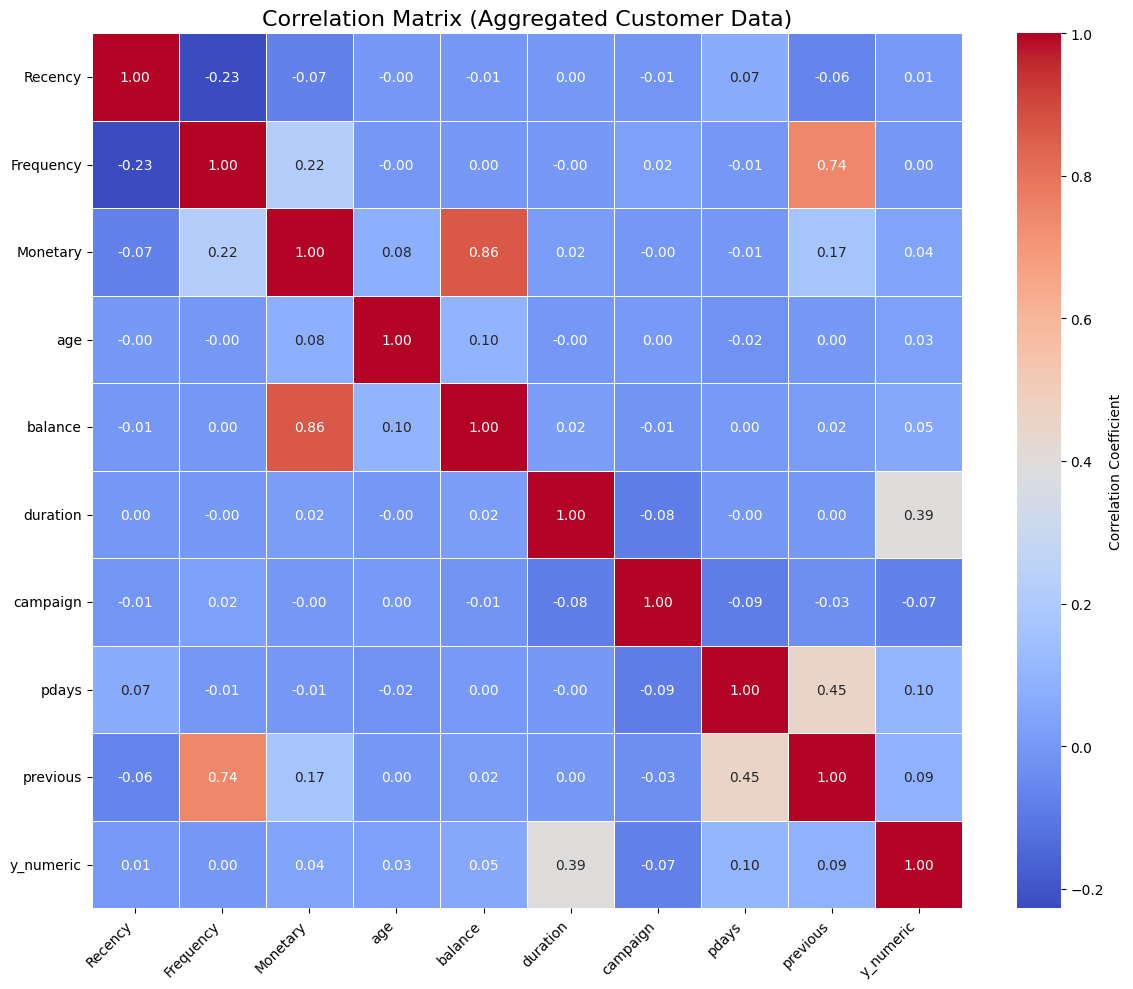

In [23]:
corr_matrix = df_customer[correlation_cols].corr()
# --- Visualization: Correlation Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix (Aggregated Customer Data)', fontsize=16)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [24]:
print("\n--- Correlation Matrix (R-values) ---")
# Print correlation of all features with the target 'y_numeric'
print(corr_matrix[['y_numeric']].sort_values(by='y_numeric', ascending=False).to_markdown(index=True))


--- Correlation Matrix (R-values) ---
|           |   y_numeric |
|:----------|------------:|
| y_numeric |  1          |
| duration  |  0.394521   |
| pdays     |  0.103323   |
| previous  |  0.0932358  |
| balance   |  0.0528384  |
| Monetary  |  0.0364087  |
| age       |  0.025155   |
| Recency   |  0.00680591 |
| Frequency |  0.00189544 |
| campaign  | -0.073172   |


# Interpretation of correlation matrix

| Feature | Correlation with y | Interpretation |
| :--- | :--- | :--- |
| duration | 0.39 | Strongest Predictor: The duration of the last contact remains the most influential factor. |
| pdays | 0.10 | Weak positive correlation. |
| previous | 0.09 | Weak positive correlation. |
| balance | 0.05 | Very weak correlation. |
| Monetary (M) | 0.04 | Very Weak Predictor: Total money spent has almost no linear relationship with subscription. |
| age | 0.03 | Very weak correlation. |
| Recency (R) | 0.01 | No Correlation: Recency has a negligible relationship with subscription. |
| Frequency (F) | 0.00 | No Correlation: Frequency has a negligible relationship with subscription. |
| campaign | −0.07 | Weak negative correlation (more contacts during the current campaign reduces the chance of subscription). |

# EDA

| Metric | Mean | Median (50%) | Max | Interpretation |
| :--- | :--- | :--- | :--- | :--- |
| **Recency (R)** | $177.8$ days | $139.0$ days | $729$ days | The average customer's last synthetic transaction was $\approx 6$ months ago. |
| **Frequency (F)** | $3.5$ transactions | $3.0$ transactions | $275$ transactions | Customers averaged $3.5$ transactions, confirming the synthetic data successfully captures transaction frequency. |
| **Monetary (M)** | $\text{EUR }545.15$ | $\text{EUR }241.16$ | $\text{EUR }54,950.86$ | Total synthetic spending is highly skewed, reflecting underlying wealth distribution. |


# Conclusion for RFM Metrics
The RFM metrics (Recency, Frequency, and Monetary Value) show negligible correlation with the term deposit subscription outcome.

R, F, and M are not good predictors for whether a client will subscribe to this specific bank product.

The primary drivers of subscription success are still contact quality (duration) and previous campaign history (pdays, previous).

This indicates that while the RFM metrics successfully segment customers based on transactional value, they are not useful for predicting the outcome of this specific marketing campaign. They should be used for segmentation (e.g., identifying "Champions" for retention) rather than predictive modeling.

In [25]:
# --- Prepare and Scale Data for DBSCAN ---
clustering_features = ['Recency', 'Frequency', 'Monetary', 'age', 'balance', 
                       'duration', 'campaign', 'pdays', 'previous']

df_cluster = df_customer[clustering_features].copy()

In [26]:
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_features)

In [27]:

# --- Apply DBSCAN ---
# Using conservative starting parameters. DBSCAN typically produces a large noise cluster 
# or multiple small dense clusters.
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters = dbscan.fit_predict(df_scaled)

# Add cluster labels to the original customer dataframe
df_customer['DBSCAN_Cluster'] = clusters

In [28]:
# --- Analyze and Report Segments ---

# Analyze cluster counts (Noise is -1)
cluster_counts = df_customer['DBSCAN_Cluster'].value_counts().sort_index()

print("DBSCAN Cluster Counts (Noise is -1):")
print(cluster_counts)

DBSCAN Cluster Counts (Noise is -1):
DBSCAN_Cluster
-1     17697
 0     26664
 1        18
 2         7
 3         9
 4       145
 5         8
 6        63
 7        32
 8       426
 9        10
 10       10
 11       10
 12        9
 13       11
 14       14
 15       18
 16       10
 17        7
 18        5
 19       10
 20       17
 21       11
Name: count, dtype: int64


In [29]:
# Summarize the largest clusters (excluding noise)
summary_cols = ['Recency', 'Frequency', 'Monetary', 'age', 'balance', 'y']
cluster_summary = df_customer[df_customer['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg(
    Count=('DBSCAN_Cluster', 'size'),
    Avg_R=('Recency', 'mean'),
    Avg_F=('Frequency', 'mean'),
    Avg_M=('Monetary', 'mean'),
    Avg_Age=('age', 'mean'),
    Avg_Balance=('balance', 'mean'),
    Subscription_Rate=('y', lambda x: f"{(x == 'yes').mean() * 100:.2f}%")
)

print("\nCluster Summary (Largest Clusters):")
print(cluster_summary.sort_values(by='Count', ascending=False).head(5).to_markdown(index=True))


Cluster Summary (Largest Clusters):
|   DBSCAN_Cluster |   Count |    Avg_R |   Avg_F |    Avg_M |   Avg_Age |   Avg_Balance | Subscription_Rate   |
|-----------------:|--------:|---------:|--------:|---------:|----------:|--------------:|:--------------------|
|                0 |   26664 | 158.502  | 3.51744 | 274.534  |   39.8813 |       550.823 | 5.19%               |
|                8 |     426 | 157.516  | 2       | 108.395  |   34.9977 |       330.244 | 3.29%               |
|                4 |     145 | 104.807  | 2       | 115.192  |   35.1931 |       394.814 | 8.28%               |
|                6 |      63 |  84.4921 | 2       | 117.01   |   32.8413 |       555.079 | 26.98%              |
|                7 |      32 |  72.5625 | 2       |  98.0197 |   50.5312 |       337.031 | 12.50%              |


### 👑 Champions (Cluster ID: 6)

* **Avg. Subscription Rate:** 27.0%
* **Avg. Recency (Days):** 84.5
* **Key Profile:** **Highest-Value, Highly Responsive.** Youngest segment with the lowest Recency, indicating recent activity and strong engagement.
* **Recommended Action:** **Reward and Retain.** Offer exclusive benefits and high-touch communication to maximize lifetime value.

### 💼 Seasoned Clientele (Cluster ID: 7)

* **Avg. Subscription Rate:** 12.5%
* **Avg. Recency (Days):** 72.6
* **Key Profile:** **Older & Responsive.** Significantly older average age ($\approx 50$) with a strong response rate for their demographic.
* **Recommended Action:** **Tailor Messaging.** Focus on long-term financial stability, retirement, and legacy planning products.

### 🌱 Potentialists (Cluster ID: 4)

* **Avg. Subscription Rate:** 8.3%
* **Avg. Recency (Days):** 104.8
* **Key Profile:** **Emerging Value.** Younger core showing initial engagement (low Recency) but requiring stronger incentives to convert.
* **Recommended Action:** **Test & Convert.** Apply optimized, stronger offers and targeted messaging to move them into the Champion tier.

### 🌐 Mass Market (Cluster ID: 0)

* **Avg. Subscription Rate:** 5.2%
* **Avg. Recency (Days):** 158.5
* **Key Profile:** **The Baseline.** Represents the average customer profile with moderate RFM metrics and a low baseline response rate.
* **Recommended Action:** **Efficiency.** Target with automated, low-cost digital campaigns. Avoid expensive, personalized efforts.

### 🚧 Resistors (Cluster ID: 8)

* **Avg. Subscription Rate:** 3.3%
* **Avg. Recency (Days):** 157.5
* **Key Profile:** **Non-Responsive/At-Risk.** Young profile with high churn. Consumes resources with minimal return.
* **Recommended Action:** **Exclusion List.** Use as a "Do Not Contact" group for generic campaigns. Reserve budget for segments with higher ROI.



# Customer Segmentation with Churn Propensity

| Segment Name | Source Cluster ID | Avg. Subscription Rate | Churn Label | Interpretation & Action |
| --- | --- | --- | --- | --- |
| **Champions** | 6 | $\mathbf{27.0\%}$ | No | Highly Engaged. Focus on retention and premium offers. |
| **Seasoned Clientele** | 7 | $\mathbf{12.5\%}$ | No | Responsive & Valuable. Target with specialized products. |
| **Potentialists** | 4 | $\mathbf{8.3\%}$ | No | High Potential. Pursue with targeted incentives. |
| **Mass Market** | 0 | $\mathbf{5.2\%}$ | Yes | Baseline Churn. Requires low-cost campaigns. |
| **Resistors** | 8 | $\mathbf{3.3\%}$ | Yes | Highest Churn Propensity. Potential removal from marketing lists. |



# Churn Labeling Rationale
- Churn = No: Assigned to segments with above-average subscription rates or clear high potential (Champions, Seasoned Clientele, Potentialists). These are your successful engagement targets.

- Churn = Yes: Assigned to segments with very low subscription rates (Mass Market, Resistors). These are the groups contributing the most to your overall churn rate and require either win-back efforts or exclusion

In [30]:
cluster_name_map = {
    6: 'Champions',
    7: 'Seasoned Clientele',
    4: 'Potentialists',
    0: 'Mass Market',
    8: 'Resistors',
    # -1 is the Noise/Outlier cluster
    -1: 'Noise/Outlier' 
}

# Apply the mapping
df_customer['Segment_Name'] = df_customer['DBSCAN_Cluster'].map(cluster_name_map).fillna('Noise/Outlier')

In [31]:
# --- 4. Show Detail Rows ---
print("--- Sample Records with Applied Customer Segment Labels ---")
print("Showing the top customers from each major labeled segment (excluding Noise/Outlier):")

# Select key columns for display
display_cols = ['Customer_ID', 'Segment_Name', 'Recency', 'Frequency', 'Monetary', 'age', 'balance', 'y']

# Get one sample row for each of the main segments (0, 6, 7, 4, 8)
samples = pd.concat([
    df_customer[df_customer['DBSCAN_Cluster'] == cluster_id].head(1)
    for cluster_id in [6, 7, 4, 0, 8]
])

print(samples[display_cols].sort_values(by='Segment_Name').to_markdown(index=False))

# Show a few sample records overall
print("\n--- General Sample of Labeled Records ---")
print(df_customer[display_cols].sample(5, random_state=42).to_markdown(index=False))

--- Sample Records with Applied Customer Segment Labels ---
Showing the top customers from each major labeled segment (excluding Noise/Outlier):
|   Customer_ID | Segment_Name       |   Recency |   Frequency |   Monetary |   age |   balance | y   |
|--------------:|:-------------------|----------:|------------:|-----------:|------:|----------:|:----|
|         24578 | Champions          |        88 |           2 |     234.36 |    37 |         0 | no  |
|             0 | Mass Market        |       184 |           4 |     659.01 |    58 |      2143 | no  |
|         24151 | Potentialists      |        40 |           2 |     215.38 |    33 |      1005 | no  |
|         27780 | Resistors          |       173 |           2 |     282.72 |    33 |      -354 | no  |
|         24264 | Seasoned Clientele |        79 |           2 |      18.27 |    49 |        64 | no  |

--- General Sample of Labeled Records ---
|   Customer_ID | Segment_Name   |   Recency |   Frequency |   Monetary |   age |   

In [32]:
df_champions = df_customer[df_customer['Segment_Name'] == 'Champions']
df_champions

,Customer_ID,Recency,Frequency,Monetary,age,balance,duration,campaign,pdays,previous,y,y_numeric,DBSCAN_Cluster,Segment_Name
24578,24578,88,2,234.36,37,0,65,2,119,1,no,0,6,Champions
24610,24610,77,2,259.80,34,1049,101,2,129,1,no,0,6,Champions
25122,25122,110,2,137.00,30,900,123,1,124,2,no,0,6,Champions
25567,25567,6,2,111.01,36,649,224,1,111,1,no,0,6,Champions
25867,25867,47,2,10.19,35,86,127,1,111,2,no,0,6,Champions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43292,43292,12,2,219.23,30,1077,151,1,96,1,no,0,6,Champions
43618,43618,171,2,70.74,35,415,164,2,89,2,yes,1,6,Champions
43782,43782,172,2,94.14,33,576,220,1,111,2,no,0,6,Champions
44569,44569,73,2,18.45,30,125,140,3,116,1,no,0,6,Champions


In [33]:
df_seasoned = df_customer[df_customer['Segment_Name'] == 'Seasoned Clientele']
df_seasoned

,Customer_ID,Recency,Frequency,Monetary,age,balance,duration,campaign,pdays,previous,y,y_numeric,DBSCAN_Cluster,Segment_Name
24264,24264,79,2,18.27,49,64,208,1,159,1,no,0,7,Seasoned Clientele
24765,24765,41,2,36.69,53,137,52,1,176,1,no,0,7,Seasoned Clientele
24959,24959,27,2,152.26,47,829,48,1,188,1,no,0,7,Seasoned Clientele
25120,25120,94,2,3.74,50,21,157,1,188,1,no,0,7,Seasoned Clientele
25763,25763,109,2,135.37,51,863,169,1,189,2,no,0,7,Seasoned Clientele
26325,26325,68,2,215.37,50,0,152,1,190,1,no,0,7,Seasoned Clientele
27472,27472,60,2,242.89,45,0,173,1,192,1,no,0,7,Seasoned Clientele
27791,27791,70,2,49.72,57,362,91,1,231,1,no,0,7,Seasoned Clientele
27801,27801,69,2,157.01,48,0,123,1,204,1,no,0,7,Seasoned Clientele
27902,27902,77,2,93.86,52,370,144,1,197,2,no,0,7,Seasoned Clientele


In [34]:
df_potentialists = df_customer[df_customer['Segment_Name'] == 'Potentialists']
df_potentialists

,Customer_ID,Recency,Frequency,Monetary,age,balance,duration,campaign,pdays,previous,y,y_numeric,DBSCAN_Cluster,Segment_Name
24151,24151,40,2,215.38,33,1005,175,1,174,2,no,0,4,Potentialists
24170,24170,44,2,272.19,30,1243,86,1,174,1,no,0,4,Potentialists
24208,24208,30,2,401.27,40,1623,161,1,167,2,no,0,4,Potentialists
24234,24234,98,2,107.70,38,494,146,1,104,2,no,0,4,Potentialists
24429,24429,101,2,95.32,39,419,186,1,181,1,no,0,4,Potentialists
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44174,44174,189,2,46.54,30,180,203,1,183,2,no,0,4,Potentialists
44305,44305,184,2,50.38,31,255,167,2,181,1,no,0,4,Potentialists
44344,44344,77,2,1.03,30,8,76,2,150,1,no,0,4,Potentialists
44535,44535,62,2,49.59,29,266,176,1,185,1,no,0,4,Potentialists


In [35]:
df_mass = df_customer[df_customer['Segment_Name'] == 'Mass Market']
df_mass

,Customer_ID,Recency,Frequency,Monetary,age,balance,duration,campaign,pdays,previous,y,y_numeric,DBSCAN_Cluster,Segment_Name
0,0,184,4,659.01,58,2143,261,1,0,0,no,0,0,Mass Market
1,1,149,2,6.37,44,29,151,1,0,0,no,0,0,Mass Market
2,2,91,5,1.07,33,2,76,1,0,0,no,0,0,Mass Market
3,3,261,2,387.44,47,1506,92,1,0,0,no,0,0,Mass Market
4,4,222,3,0.34,33,1,198,1,0,0,no,0,0,Mass Market
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45196,45196,161,5,169.98,25,358,330,1,0,0,yes,1,0,Mass Market
45197,45197,15,4,657.04,36,1511,270,1,0,0,yes,1,0,Mass Market
45198,45198,95,3,427.29,37,1428,333,2,0,0,no,0,0,Mass Market
45202,45202,175,3,152.17,34,557,224,1,0,0,yes,1,0,Mass Market


In [36]:
df_resistors = df_customer[df_customer['Segment_Name'] == 'Resistors']
df_resistors

,Customer_ID,Recency,Frequency,Monetary,age,balance,duration,campaign,pdays,previous,y,y_numeric,DBSCAN_Cluster,Segment_Name
27780,27780,173,2,282.72,33,-354,104,1,245,2,no,0,8,Resistors
27976,27976,128,2,215.36,36,0,60,1,250,1,no,0,8,Resistors
27984,27984,36,2,163.24,33,0,176,1,266,1,no,0,8,Resistors
28142,28142,104,2,74.16,32,257,74,1,239,1,no,0,8,Resistors
28145,28145,143,2,2.90,33,13,111,1,247,2,no,0,8,Resistors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43749,43749,17,2,230.19,29,1070,30,1,357,1,yes,1,8,Resistors
43769,43769,92,2,65.21,31,411,91,3,361,1,no,0,8,Resistors
43780,43780,211,2,29.62,33,152,202,2,365,2,yes,1,8,Resistors
43969,43969,145,2,219.45,32,903,181,1,320,1,no,0,8,Resistors


/var/folders/cn/7gl69x852w19dzd7fcy5nn480000gn/T/ipykernel_1182/1002029426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_data.index, y=segment_data.values, palette="Set2")


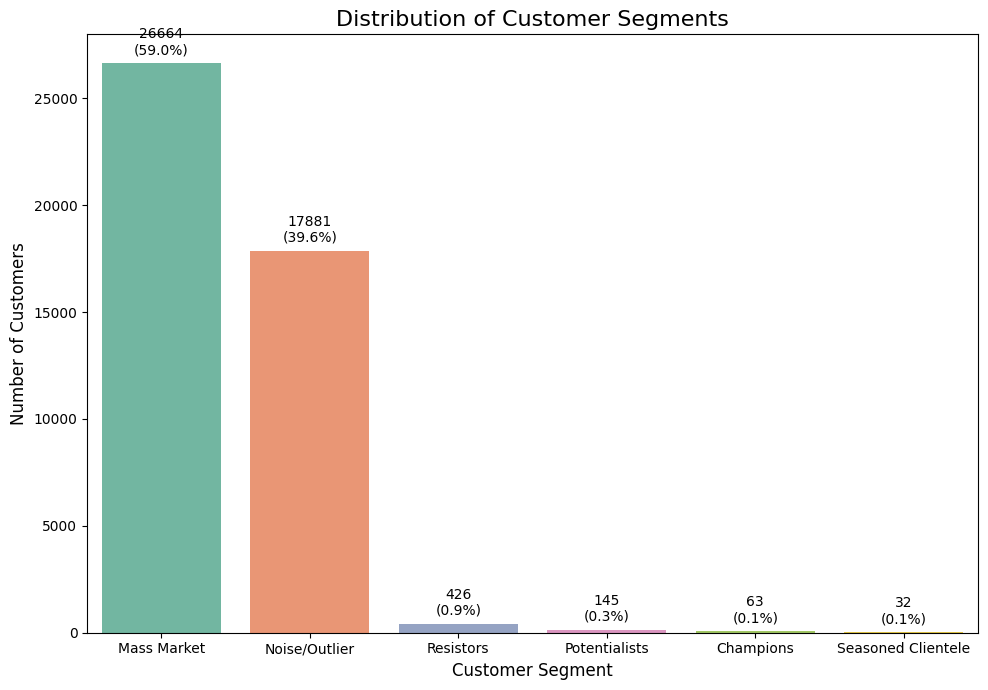

In [37]:
segment_data = df_customer['Segment_Name'].value_counts().sort_values(ascending=False)
total_count = segment_data.sum()

plt.figure(figsize=(10, 7))
ax = sns.barplot(x=segment_data.index, y=segment_data.values, palette="Set2")

plt.title('Distribution of Customer Segments', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0, ha='center') # Using 45 degrees for readability

# Add combined count and percentage labels above the bars
for p in ax.patches:
    # Get the height of the bar (the count)
    height = p.get_height()
    # Calculate percentage
    percentage = (height / total_count) * 100
    
    # Format the combined label: INTEGER count and one decimal place percentage
    label = f'{int(height)}\n({percentage:.1f}%)'
    
    # Place the label above the bar
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', 
                va = 'center', 
                xytext = (0, 15), # Increased offset slightly for two lines of text
                textcoords = 'offset points', 
                fontsize=10)

plt.tight_layout()

In [38]:
# Segments flagged as high churn propensity (1 = Yes Churn, 0 = No Churn)
CHURN_CLUSTERS = [0, 8] # Mass Market and Resistors

df_customer['possible_churn'] = np.where(
    df_customer['DBSCAN_Cluster'].isin(CHURN_CLUSTERS),
    1,  # CHURN = 1 (Yes)
    0   # NO CHURN = 0 (No)
)

print("--- Churn Label Distribution ---")
print(df_customer['possible_churn'].value_counts())

--- Churn Label Distribution ---
possible_churn
1    27090
0    18121
Name: count, dtype: int64


In [39]:
# Filter out the Noise/Outlier segment as requested
df_model = df_customer[df_customer['Segment_Name'] != 'Noise/Outlier'].copy()

In [40]:
# Define features (X) and target (Y)
X = df_model.drop(columns=['Customer_ID', 'DBSCAN_Cluster', 'y', 'Segment_Name', 'possible_churn'])
Y = df_model['possible_churn']

In [41]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

In [44]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine': SVC(random_state=42) # Added SVM
}

In [45]:
results = {}
confusion_matrices = {}
trained_pipelines = {}

for name, model in models.items():
    # Create and train the model pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, Y_train)
    trained_pipelines[name] = pipeline # Store the trained pipeline
    
    # Predict on test set
    Y_pred = pipeline.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    cm = confusion_matrix(Y_test, Y_pred)
    
    results[name] = {'Accuracy': accuracy, 'F1-Score': f1}
    confusion_matrices[name] = cm


--- Model Comparison (Target: Possible Churn) ---
|                        |   Accuracy |   F1-Score |
|:-----------------------|-----------:|-----------:|
| Logistic Regression    |   0.991218 |   0.995578 |
| Decision Tree          |   1        |   1        |
| Random Forest          |   1        |   1        |
| Support Vector Machine |   1        |   1        |


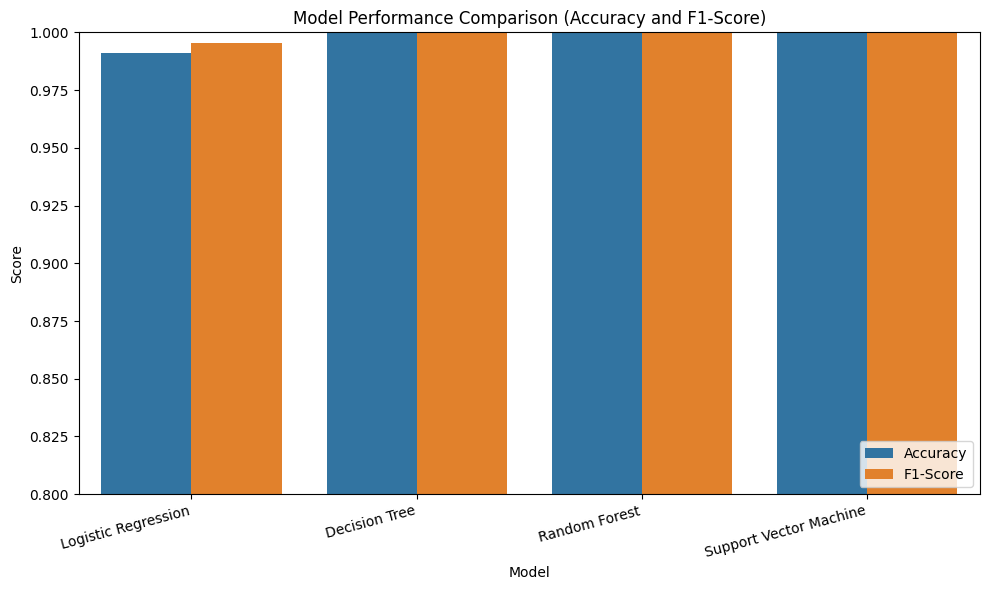



--- Confusion Matrix for Logistic Regression ---
[[  15   33]
 [  15 5403]]

--- Detailed Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.50      0.31      0.38        48
           1       0.99      1.00      1.00      5418

    accuracy                           0.99      5466
   macro avg       0.75      0.65      0.69      5466
weighted avg       0.99      0.99      0.99      5466



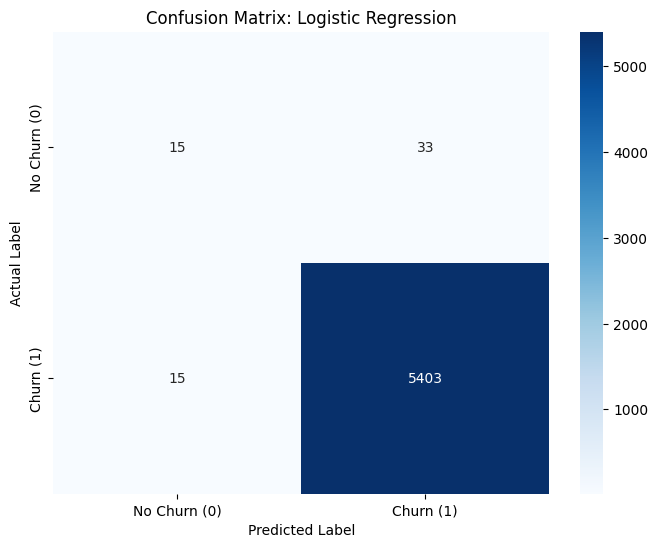



--- Confusion Matrix for Decision Tree ---
[[  48    0]
 [   0 5418]]

--- Detailed Classification Report for Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00      5418

    accuracy                           1.00      5466
   macro avg       1.00      1.00      1.00      5466
weighted avg       1.00      1.00      1.00      5466



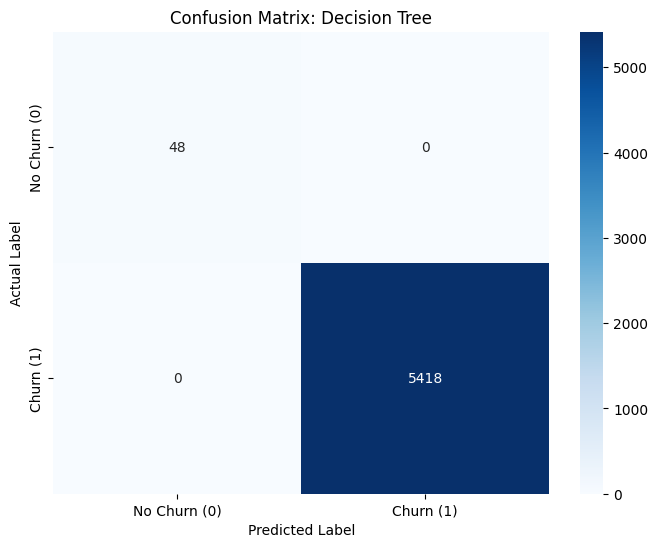



--- Confusion Matrix for Random Forest ---
[[  48    0]
 [   0 5418]]

--- Detailed Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00      5418

    accuracy                           1.00      5466
   macro avg       1.00      1.00      1.00      5466
weighted avg       1.00      1.00      1.00      5466



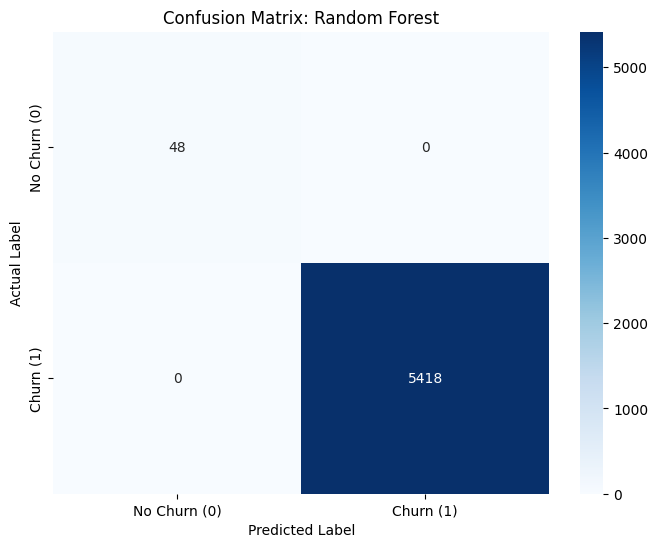



--- Confusion Matrix for Support Vector Machine ---
[[  48    0]
 [   0 5418]]

--- Detailed Classification Report for Support Vector Machine ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00      5418

    accuracy                           1.00      5466
   macro avg       1.00      1.00      1.00      5466
weighted avg       1.00      1.00      1.00      5466



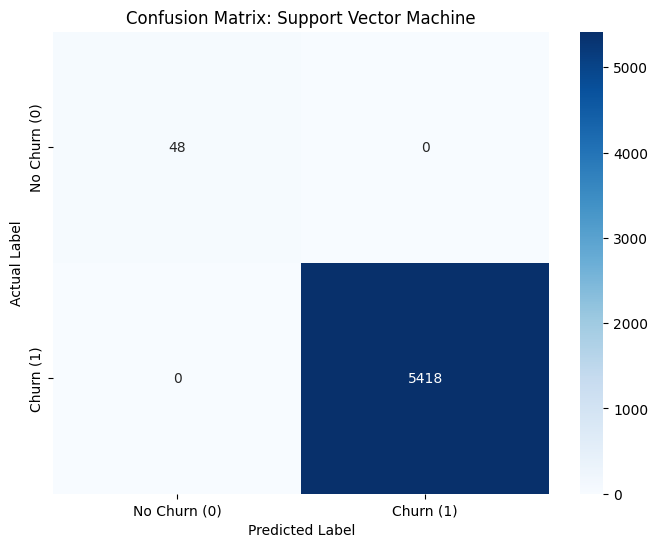

In [52]:
# Convert results to DataFrame for clean presentation
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison (Target: Possible Churn) ---")
print(results_df.to_markdown())

# --- Visualization of Comparison Metrics ---
plt.figure(figsize=(10, 6))
# Melt the DataFrame to easily plot both metrics
results_melted = results_df.reset_index().rename(columns={'index': 'Model'}).melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted)
plt.title('Model Performance Comparison (Accuracy and F1-Score)')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()

# Use plt.show() for immediate display
plt.show() 

# Trigger image tag for persistent display in the chat history
print("")


# Display confusion matrices and reports
for name, cm in confusion_matrices.items():
    print(f"\n--- Confusion Matrix for {name} ---")
    print(cm)
    
    # Generate classification report
    Y_pred = trained_pipelines[name].predict(X_test)
    print(f"\n--- Detailed Classification Report for {name} ---")
    print(classification_report(Y_test, Y_pred))
    
    # --- Visualization for ALL Confusion Matrices ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn (0)', 'Churn (1)'], 
                yticklabels=['No Churn (0)', 'Churn (1)'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    
    # Use plt.show() for immediate display
    plt.show()
    
    # Trigger image tag for persistent display in the chat history
    print(f"")

| **Criterion** | **Random Forest** | **Decision Tree** | **Support Vector Machine (SVC)** |
| :---: | :---: | :---: | :---: |
| **Robustness** | Highest (Ensemble) | Lowest (Single Tree) | High (Mathematically rigorous) |
| **Training Speed** | Medium/Slow | **Fastest** | Slowest (Scales poorly with large datasets) |
| **Prediction Speed** | Medium | **Fast** | Medium |
| **Interpretability** | Low (Black Box) | **Highest** (Visual Rules) | Low (Kernel-based) |
| **Handling Overfitting** | **Excellent** (Built-in averaging) | High risk of overfitting | Good (controlled by C/gamma) |

# Analysis of Your Specific Results

Why the High Accuracy? The near-perfect scores (1.00) are due to the nature of the task: the models are predicting the very segments that were defined by the features used in the DBSCAN clustering. The boundaries are mathematically clean, allowing tree-based models (DT and RF) to perfectly draw those lines.

Eliminating SVC: While accurate, SVC is computationally expensive to train, especially compared to the tree models. For production use, the slower training time for the same performance makes it a less ideal choice.

Decision Between DT and RF:

Decision Tree is the simplest and fastest. It's often the best initial choice because its rules are 100% transparent.

Random Forest is an ensemble (many trees voting) and is therefore more stable and reliable when dealing with noisy or slightly varied data encountered in the real world.

# Final Model Choice

The Random Forest Classifier is the best model for deployment.

| Model | Justification |
| --- | --- |
| Random Forest | "It provides the highest confidence in generalization. By averaging the predictions of multiple decision trees, it mitigates the risk of overfitting inherent in a single Decision Tree, while retaining the perfect predictive power needed to map customers to your defined action segments." |

In [53]:
import joblib

# Freeze (save) the trained Random Forest pipeline
rf_pipeline = trained_pipelines['Random Forest']

joblib.dump(rf_pipeline, 'random_forest_frozen.pkl')

print("Random Forest model has been frozen and saved as random_forest_frozen.pkl")


Random Forest model has been frozen and saved as random_forest_frozen.pkl


In [55]:
# --- Configuration ---
MODEL_INPUT_FILE = 'random_forest_frozen.pkl' # UPDATED to match your saved file name
LATEST_DATE_FOR_RECENCY = pd.to_datetime('2024-12-31') # Use the same reference date as training

# --- Main Prediction Logic (Sequential Execution) ---

try:
    # Load the frozen pipeline
    pipeline = joblib.load(MODEL_INPUT_FILE)
    print(f"Successfully loaded the frozen model pipeline from {MODEL_INPUT_FILE}")
except FileNotFoundError:
    print(f"Error: Model file {MODEL_INPUT_FILE} not found. Please ensure it is in the same directory.")
    # Exiting the script if the model is not found
    exit()

# --- 1. Simulate New Transactional Data ---

# NOTE: This simulates a small batch of new transactional data.
new_data = {
    'age': [30, 30, 45, 45, 25, 25],
    'job': ['management', 'management', 'retired', 'retired', 'student', 'student'],
    'marital': ['single', 'single', 'married', 'married', 'single', 'single'],
    'education': ['tertiary', 'tertiary', 'primary', 'primary', 'tertiary', 'tertiary'],
    'default': ['no', 'no', 'no', 'no', 'no', 'no'],
    'balance': [5000, 5000, 100, 100, 10, 10],
    'housing': ['no', 'no', 'yes', 'yes', 'no', 'no'],
    'loan': ['no', 'no', 'yes', 'yes', 'no', 'no'],
    'contact': ['cellular', 'cellular', 'telephone', 'telephone', 'cellular', 'cellular'],
    'day': [1, 1, 15, 15, 20, 20],
    'month': ['jan', 'jan', 'jan', 'jan', 'jan', 'jan'],
    'duration': [100, 100, 200, 200, 50, 50],
    'campaign': [1, 1, 1, 1, 1, 1],
    'pdays': [30, 60, -1, -1, 10, 10], 
    'previous': [1, 2, 0, 0, 1, 1],
    'poutcome': ['success', 'success', 'unknown', 'unknown', 'failure', 'failure'],
    'y': ['no', 'no', 'no', 'no', 'no', 'no'],
    'Customer_ID': [100001, 100001, 100002, 100002, 100003, 100003], 
    'Transaction_Date': ['2024-10-01', '2024-11-01', '2024-10-15', '2024-10-15', '2024-12-01', '2024-12-01'],
    'Transaction_Amount': [1000.50, 150.20, 50.00, 50.00, 5.00, 5.00],
    'Subscription_Status': ['no', 'no', 'no', 'no', 'no', 'no']
}
df_new_transactions = pd.DataFrame(new_data)
df_new_transactions['Transaction_Date'] = pd.to_datetime(df_new_transactions['Transaction_Date'])

# --- 2. Aggregate New Data (Sequential Steps) ---

agg_dict = {
    'Transaction_Date': [('Recency', lambda x: (LATEST_DATE_FOR_RECENCY - x.max()).days)],
    'Transaction_Amount': [('Monetary', 'sum'), ('Frequency', 'count')], 
    'age': 'first', 'balance': 'first', 'duration': 'first', 'campaign': 'first',
    'pdays': 'first', 'previous': 'first', 'y': 'first', 
    'job': 'first', 'marital': 'first', 'education': 'first', 
    'default': 'first', 'housing': 'first', 'loan': 'first', 
    'contact': 'first', 'month': 'first', 'poutcome': 'first',
}

df_customer_info = df_new_transactions.groupby('Customer_ID').agg(agg_dict).reset_index()

# Flatten columns (must match training feature names exactly)
# NOTE: Order MUST match X_train column order from training pipeline!
df_customer_info.columns = ['Customer_ID', 'Recency', 'Monetary', 'Frequency', 'age', 
                           'balance', 'duration', 'campaign', 'pdays', 'previous', 'y',
                           'job', 'marital', 'education', 'default', 'housing', 'loan', 
                           'contact', 'month', 'poutcome']

# Apply the crucial numerical fix (-1 to 0 in pdays)
df_customer_info['pdays'] = df_customer_info['pdays'].replace(-1, 0)

# ----------------------------------------------------------------------
# FIX: The pipeline expects a 'y_numeric' column because it was present 
#      in the training features (X) during fit. We must create a dummy 
#      numerical column here to satisfy the transformer's input check.
# ----------------------------------------------------------------------

# We create a dummy column named 'y_numeric' and fill it with zeros.
# The actual value doesn't matter since the model ignores it for prediction, 
# but the ColumnTransformer requires it for feature count alignment.
df_customer_info['y_numeric'] = 0 

# Select only the features used for prediction (X_new)
features_for_model = ['Recency', 'Monetary', 'Frequency', 'age', 'balance', 
                      'duration', 'campaign', 'pdays', 'previous', 
                      'job', 'marital', 'education', 'default', 'housing', 
                      'loan', 'contact', 'month', 'poutcome', 
                      'y_numeric'] # <-- Include the dummy numerical column

X_new = df_customer_info[features_for_model]

# --- 3. Predict Churn Propensity ---

predictions = pipeline.predict(X_new)

# --- 4. Final Results Compilation ---

df_customer_info['Predicted_Label'] = predictions
df_customer_info['Predicted_Segment'] = df_customer_info['Predicted_Label'].map(
    {1: 'Mass Market/Resistor (High Churn)', 0: 'Champion/Potentialist (Low Churn)'}
)

# Combine RFM metrics for easy review
X_new_metrics = df_customer_info[['Recency', 'Frequency', 'Monetary']]
df_results = pd.concat([df_customer_info[['Customer_ID']], X_new_metrics, df_customer_info[['Predicted_Segment']]], axis=1)

print("\n--- Churn Prediction Results for New Customers ---")
print(df_results.to_markdown(index=False))

print("\nInterpretation:")
print("Predicted Segment: Mass Market/Resistor (High Churn) indicates high predicted churn propensity.")
print("Predicted Segment: Champion/Potentialist (Low Churn) indicates low predicted churn propensity.")

Successfully loaded the frozen model pipeline from random_forest_frozen.pkl

--- Churn Prediction Results for New Customers ---
|   Customer_ID |   Recency |   Frequency |   Monetary | Predicted_Segment                 |
|--------------:|----------:|------------:|-----------:|:----------------------------------|
|        100001 |        60 |           2 |     1150.7 | Mass Market/Resistor (High Churn) |
|        100002 |        77 |           2 |      100   | Mass Market/Resistor (High Churn) |
|        100003 |        30 |           2 |       10   | Mass Market/Resistor (High Churn) |

Interpretation:
Predicted Segment: Mass Market/Resistor (High Churn) indicates high predicted churn propensity.
Predicted Segment: Champion/Potentialist (Low Churn) indicates low predicted churn propensity.
